# rMATS single-cell splice-count EDA

This notebook summarizes the all-event rMATS single-cell output and builds count-based and PSI-based UMAPs colored by cell type.

Run this on a compute node. The full all-event sparse matrices are large, so the reductions stay sparse and the UMAP cells default to a random subsample.

In [1]:
from pathlib import Path
import os
import textwrap

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')

import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
from IPython.display import display
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_bar,
    geom_histogram,
    geom_label,
    geom_point,
    ggplot,
    ggtitle,
    guides,
    guide_legend,
    labs,
    scale_color_manual,
    theme,
    theme_bw,
)
from scipy.sparse.linalg import LinearOperator
from sklearn.decomposition import TruncatedSVD
from umap.umap_ import UMAP

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)

FINAL_DIR = Path('/gpfs/commons/home/nkeung/tabula_muris_data/psi_data/final_data_all_events_parquet')
H5AD = FINAL_DIR / 'cell_event_counts.h5ad'
INC_NPZ = FINAL_DIR / 'cell_event_inclusion_count.npz'
EXC_NPZ = FINAL_DIR / 'cell_event_exclusion_count.npz'
OBS_NPZ = FINAL_DIR / 'cell_event_count_observed.npz'
PSI_OBS_NPZ = FINAL_DIR / 'cell_event_observed.npz'
PSI_NPZ = FINAL_DIR / 'cell_event_psi.npz'

for path in [H5AD, INC_NPZ, EXC_NPZ, OBS_NPZ, PSI_OBS_NPZ, PSI_NPZ]:
    if not path.exists():
        raise FileNotFoundError(path)

print(FINAL_DIR)

/gpfs/commons/home/daknowles/venv/torchfix/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


/gpfs/commons/home/nkeung/tabula_muris_data/psi_data/final_data_all_events_parquet


## Metadata and Matrix Shape

In [2]:
adata_meta = ad.read_h5ad(H5AD, backed='r')
print(adata_meta)
print('layers:', list(adata_meta.layers.keys()))
print('obs columns:', list(adata_meta.obs.columns))
print('var columns:', list(adata_meta.var.columns))

obs = adata_meta.obs.copy()
var = adata_meta.var.copy()
adata_meta.file.close()

cell_type_candidates = ['cell_type', 'cell_ontology_class', 'sample_label', 'label']
cell_type_col = next((col for col in cell_type_candidates if col in obs.columns), None)
if cell_type_col is None:
    object_cols = obs.select_dtypes(include=['object', 'category']).columns
    cell_type_col = object_cols[0] if len(object_cols) else None
print('cell type column:', cell_type_col)

required_var_cols = ['event_type', 'incformlen', 'skipformlen', 'event_coordinates']
print('required var columns present:', {col: col in var.columns for col in required_var_cols})

event_type_counts = var['event_type'].value_counts().rename_axis('event_type').reset_index(name='n_events')
display(event_type_counts)

AnnData object with n_obs × n_vars = 107521 × 128990 backed at '/gpfs/commons/home/nkeung/tabula_muris_data/psi_data/final_data_all_events_parquet/cell_event_counts.h5ad'
    obs: 'cell_index', 'cell_id', 'safe_cell_id', 'cell_type', 'bam_path', 'n_events_observed', 'missing_psi_table'
    var: 'event_index', 'event_type', 'exon_strand', 'event_coordinates', 'gene_type', 'gene_id', 'gene_symbol', 'exon_location', 'exon_boundary', 'chromosome', 'incformlen', 'skipformlen', 'event_id', '1stExonEnd', '1stExonStart_0base', '2ndExonEnd', '2ndExonStart_0base', 'downstreamEE', 'downstreamES', 'exonEnd', 'exonStart_0base', 'flankingEE', 'flankingES', 'longExonEnd', 'longExonStart_0base', 'riExonEnd', 'riExonStart_0base', 'shortEE', 'shortES', 'upstreamEE', 'upstreamES'
    uns: 'X_name'
    layers: 'count_observed', 'exclusion_count', 'psi', 'psi_observed'
layers: ['count_observed', 'exclusion_count', 'psi', 'psi_observed']
obs columns: ['cell_index', 'cell_id', 'safe_cell_id', 'cell_type', 'b

,event_type,n_events
0,SE,105189
1,A3SS,7841
2,MXE,6639
3,A5SS,4790
4,RI,4531


## Sparse Count Summaries

`count_observed` records cell-event pairs where at least one count was positive. Inclusion and exclusion counts are stored separately; explicit zero counts are not stored in those count matrices.

In [3]:
inc = sp.load_npz(INC_NPZ).tocsr()
exc = sp.load_npz(EXC_NPZ).tocsr()
count_obs = sp.load_npz(OBS_NPZ).tocsr()

print('inclusion:', inc.shape, 'nnz=', f'{inc.nnz:,}', 'explicit zeros=', int((inc.data == 0).sum()))
print('exclusion:', exc.shape, 'nnz=', f'{exc.nnz:,}', 'explicit zeros=', int((exc.data == 0).sum()))
print('count observed:', count_obs.shape, 'nnz=', f'{count_obs.nnz:,}', 'explicit zeros=', int((count_obs.data == 0).sum()))

events_per_cell = count_obs.getnnz(axis=1)
cells_per_event = count_obs.getnnz(axis=0)
inc_per_cell = np.asarray(inc.sum(axis=1)).ravel()
exc_per_cell = np.asarray(exc.sum(axis=1)).ravel()
total_count_per_cell = inc_per_cell + exc_per_cell
inc_per_event = np.asarray(inc.sum(axis=0)).ravel()
exc_per_event = np.asarray(exc.sum(axis=0)).ravel()
total_count_per_event = inc_per_event + exc_per_event

summary = pd.DataFrame({
    'metric': [
        'events_per_cell', 'cells_per_event', 'total_count_per_cell', 'total_count_per_event',
        'inclusion_count_per_cell', 'exclusion_count_per_cell',
    ],
    'min': [events_per_cell.min(), cells_per_event.min(), total_count_per_cell.min(), total_count_per_event.min(), inc_per_cell.min(), exc_per_cell.min()],
    'median': [np.median(events_per_cell), np.median(cells_per_event), np.median(total_count_per_cell), np.median(total_count_per_event), np.median(inc_per_cell), np.median(exc_per_cell)],
    'mean': [events_per_cell.mean(), cells_per_event.mean(), total_count_per_cell.mean(), total_count_per_event.mean(), inc_per_cell.mean(), exc_per_cell.mean()],
    'max': [events_per_cell.max(), cells_per_event.max(), total_count_per_cell.max(), total_count_per_event.max(), inc_per_cell.max(), exc_per_cell.max()],
})
display(summary)

event_qc = pd.DataFrame({
    'event_type': var['event_type'].astype(str).values,
    'cells_per_event': cells_per_event,
    'inclusion_count': inc_per_event,
    'exclusion_count': exc_per_event,
    'total_count': total_count_per_event,
}, index=var.index)

event_type_qc = event_qc.groupby('event_type').agg(
    n_events=('cells_per_event', 'size'),
    median_cells=('cells_per_event', 'median'),
    median_total_count=('total_count', 'median'),
    total_inclusion_count=('inclusion_count', 'sum'),
    total_exclusion_count=('exclusion_count', 'sum'),
).sort_values('n_events', ascending=False)
display(event_type_qc)

inclusion: (107521, 128990) nnz= 137,786,592 explicit zeros= 0
exclusion: (107521, 128990) nnz= 113,969,657 explicit zeros= 0


count observed: (107521, 128990) nnz= 234,285,123 explicit zeros= 0


,metric,min,median,mean,max
0,events_per_cell,2.0,1778.0,2178.970834,14802.0
1,cells_per_event,0.0,8.0,1816.304543,99163.0
2,total_count_per_cell,2.0,147749.0,232430.500000,25768556.0
3,total_count_per_event,0.0,359.0,193743.937500,377888384.0
4,inclusion_count_per_cell,0.0,96628.0,154339.625000,18265704.0
5,exclusion_count_per_cell,0.0,49743.0,78090.851562,7687515.0


,n_events,median_cells,median_total_count,total_inclusion_count,total_exclusion_count
event_type,,,,,
SE,105189,6.0,250.0,1.142196e+10,2.860983e+09
A3SS,7841,446.0,12759.0,2.261850e+09,1.545691e+09
MXE,6639,3.0,298.0,2.361104e+08,3.026218e+08
A5SS,4790,266.0,7836.5,1.046430e+09,5.560564e+08
RI,4531,2909.0,101878.0,1.628311e+09,3.131020e+09


## Histograms

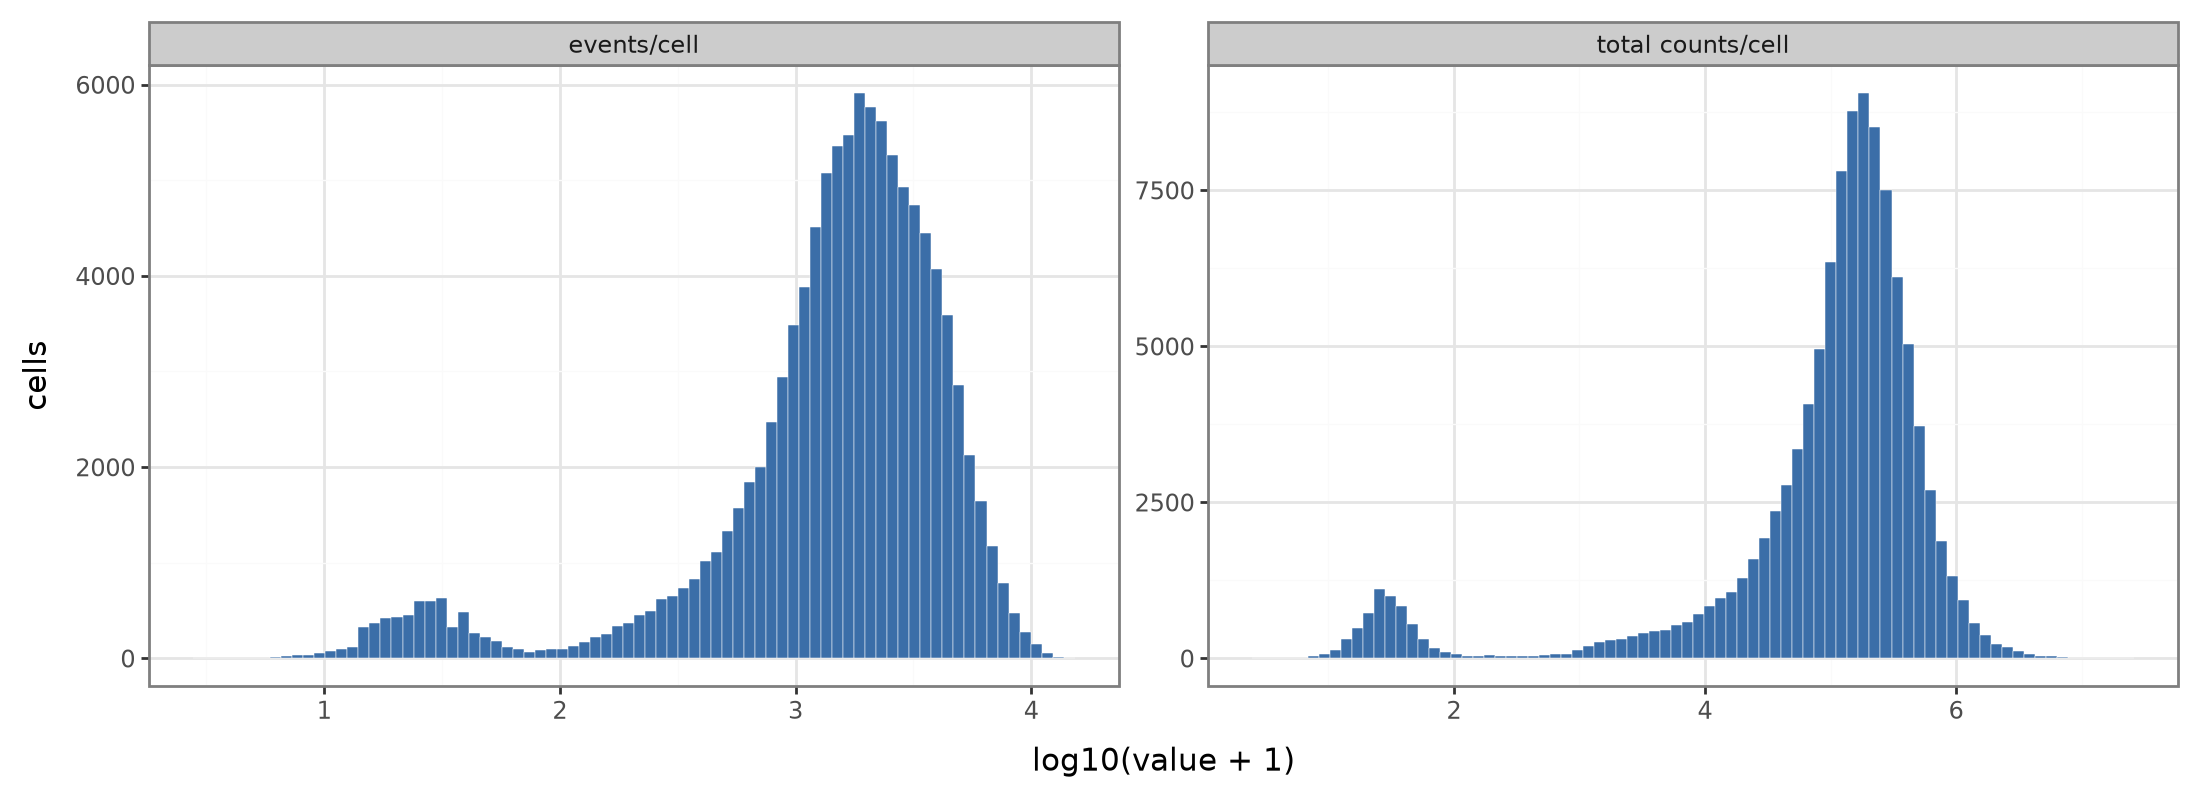

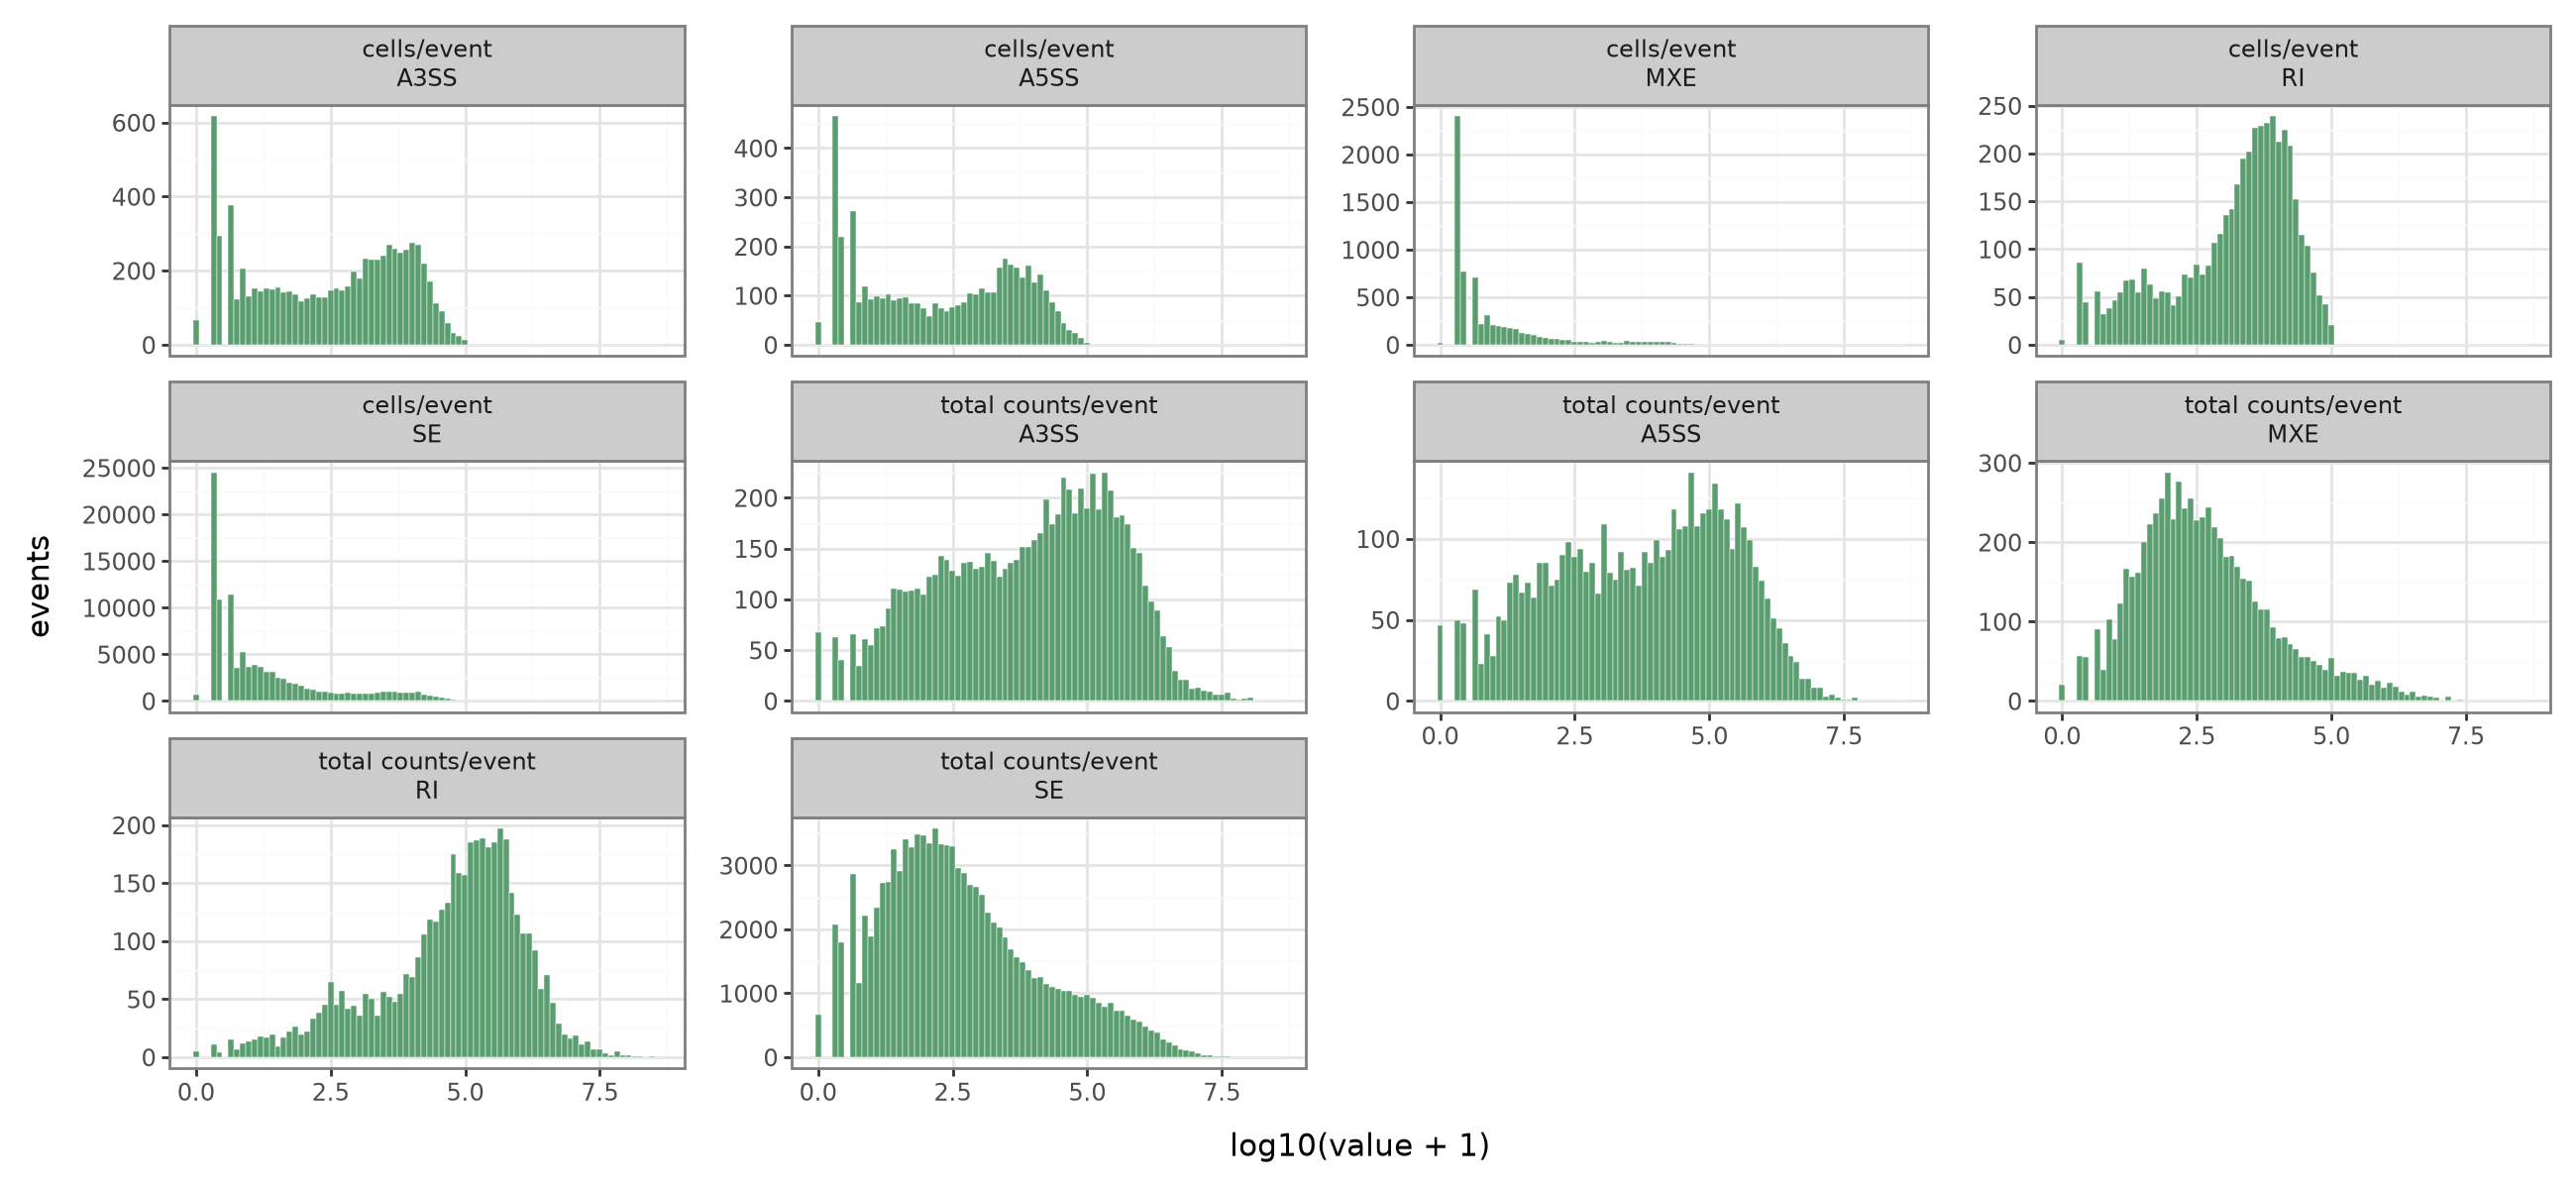

In [4]:
cell_hist_df = pd.concat([
    pd.DataFrame({'metric': 'events/cell', 'log10_value': np.log10(events_per_cell + 1)}),
    pd.DataFrame({'metric': 'total counts/cell', 'log10_value': np.log10(total_count_per_cell + 1)}),
], ignore_index=True)

event_hist_df = pd.concat([
    pd.DataFrame({'event_type': event_qc['event_type'].values, 'metric': 'cells/event', 'log10_value': np.log10(cells_per_event + 1)}),
    pd.DataFrame({'event_type': event_qc['event_type'].values, 'metric': 'total counts/event', 'log10_value': np.log10(total_count_per_event + 1)}),
], ignore_index=True)

p_cells = (
    ggplot(cell_hist_df, aes('log10_value'))
    + geom_histogram(bins=80, fill='#3b6ea8', color='white', size=0.1)
    + facet_wrap('~metric', scales='free')
    + labs(x='log10(value + 1)', y='cells')
    + theme_bw()
    + theme(figure_size=(11, 4))
)
display(p_cells)

p_events = (
    ggplot(event_hist_df, aes('log10_value'))
    + geom_histogram(bins=80, fill='#5a9e6f', color='white', size=0.1)
    + facet_wrap('~ metric + event_type', scales='free_y')
    + labs(x='log10(value + 1)', y='events')
    + theme_bw()
    + theme(figure_size=(13, 6), axis_text_x=element_text(rotation=0))
)
display(p_events)

## Cell-Type QC Summaries

In [5]:
cell_qc = pd.DataFrame({
    'events_per_cell': events_per_cell,
    'total_count': total_count_per_cell,
    'inclusion_count': inc_per_cell,
    'exclusion_count': exc_per_cell,
}, index=obs.index)
if cell_type_col is not None:
    cell_qc[cell_type_col] = obs[cell_type_col].values
    by_type = cell_qc.groupby(cell_type_col).agg(
        n_cells=('events_per_cell', 'size'),
        median_events=('events_per_cell', 'median'),
        median_total_count=('total_count', 'median'),
    ).sort_values('n_cells', ascending=False)
    display(by_type.head(30))
else:
    print('No cell type column found in obs.')

/scratch/ipykernel_447840/1918077389.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,n_cells,median_events,median_total_count
cell_type,,,
microglial cell,12796,1443.0,140597.0
B cell,5526,1318.0,133097.5
endothelial cell,4812,1373.0,120679.0
mesenchymal stem cell of adipose,4532,3131.0,213652.5
basal cell of epidermis,4148,3179.0,163574.0
fibroblast of cardiac tissue,3825,2540.0,178759.0
hematopoietic stem cell,3162,4308.5,215285.5
granulocyte,2912,714.0,74240.0
naive B cell,2893,1209.0,149618.0


## Count UMAP by Cell Type

This uses a random subsample by default. It removes cells with fewer than `1e4` total inclusion+exclusion counts and events with fewer than `1000` total counts, normalizes total counts per cell, log-transforms, projects with randomized SVD, and runs UMAP.

In [6]:
N_CELLS_FOR_UMAP = None
N_COMPONENTS = 50
RANDOM_STATE = 13
MIN_TOTAL_COUNT_PER_CELL = 1e4
MIN_TOTAL_COUNT_PER_EVENT = 1000

rng = np.random.default_rng(RANDOM_STATE)
n_cells, n_events = inc.shape
eligible_cell_idx = np.flatnonzero(total_count_per_cell >= MIN_TOTAL_COUNT_PER_CELL)
eligible_event_idx = np.flatnonzero(total_count_per_event >= MIN_TOTAL_COUNT_PER_EVENT)
print(f'Cells retained for UMAP QC: {len(eligible_cell_idx):,} / {n_cells:,} (total count >= {MIN_TOTAL_COUNT_PER_CELL:,.0f})')
print(f'Events retained for UMAP QC: {len(eligible_event_idx):,} / {n_events:,} (total count >= {MIN_TOTAL_COUNT_PER_EVENT:,.0f})')
print('Retained events by type:')
display(var.iloc[eligible_event_idx]['event_type'].value_counts().rename_axis('event_type').reset_index(name='n_events'))

if len(eligible_cell_idx) == 0:
    raise ValueError('No cells passed the UMAP total-count filter')
if len(eligible_event_idx) == 0:
    raise ValueError('No events passed the UMAP total-count filter')

if N_CELLS_FOR_UMAP is None or N_CELLS_FOR_UMAP >= len(eligible_cell_idx):
    sample_idx = eligible_cell_idx
else:
    sample_idx = np.sort(rng.choice(eligible_cell_idx, size=N_CELLS_FOR_UMAP, replace=False))

X_counts = (inc[sample_idx][:, eligible_event_idx] + exc[sample_idx][:, eligible_event_idx]).astype(np.float32).tocsr()
cell_totals_for_umap = np.asarray(X_counts.sum(axis=1)).ravel()
scale = np.divide(1e4, cell_totals_for_umap, out=np.zeros_like(cell_totals_for_umap, dtype=np.float32), where=cell_totals_for_umap > 0)
X_norm = sp.diags(scale).dot(X_counts)
X_norm.data = np.log1p(X_norm.data)

n_components = min(N_COMPONENTS, X_norm.shape[0] - 1, X_norm.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_norm)
print('Count SVD explained variance ratio sum:', svd.explained_variance_ratio_.sum())

reducer = UMAP(n_neighbors=30, min_dist=0.3, metric='euclidean', random_state=RANDOM_STATE, n_jobs=1, verbose=False)
embedding = reducer.fit_transform(X_svd)

umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'], index=obs.index[sample_idx])
if cell_type_col is not None:
    umap_df[cell_type_col] = obs.iloc[sample_idx][cell_type_col].astype(str).values
umap_df.head()

Cells retained for UMAP QC: 96,417 / 107,521 (total count >= 10,000)
Events retained for UMAP QC: 51,075 / 128,990 (total count >= 1,000)
Retained events by type:


,event_type,n_events
0,SE,36495
1,A3SS,5358
2,RI,3899
3,A5SS,3095
4,MXE,2228


Count SVD explained variance ratio sum: 0.2575903


,UMAP1,UMAP2,cell_type
safe_cell_id,,,
A1-B000971-3_39_F-1-1,-7.608188,8.473267,B cell
A1-MAA000508-3_9_M-1-1,-8.308098,7.568131,B cell
A1-MAA000779-3_11_M-1-1,-7.898926,7.232829,B cell
A10-MAA000556-3_9_M-1-1,-8.214826,7.658174,B cell
A10-MAA000779-3_11_M-1-1,-8.084716,6.592475,B cell


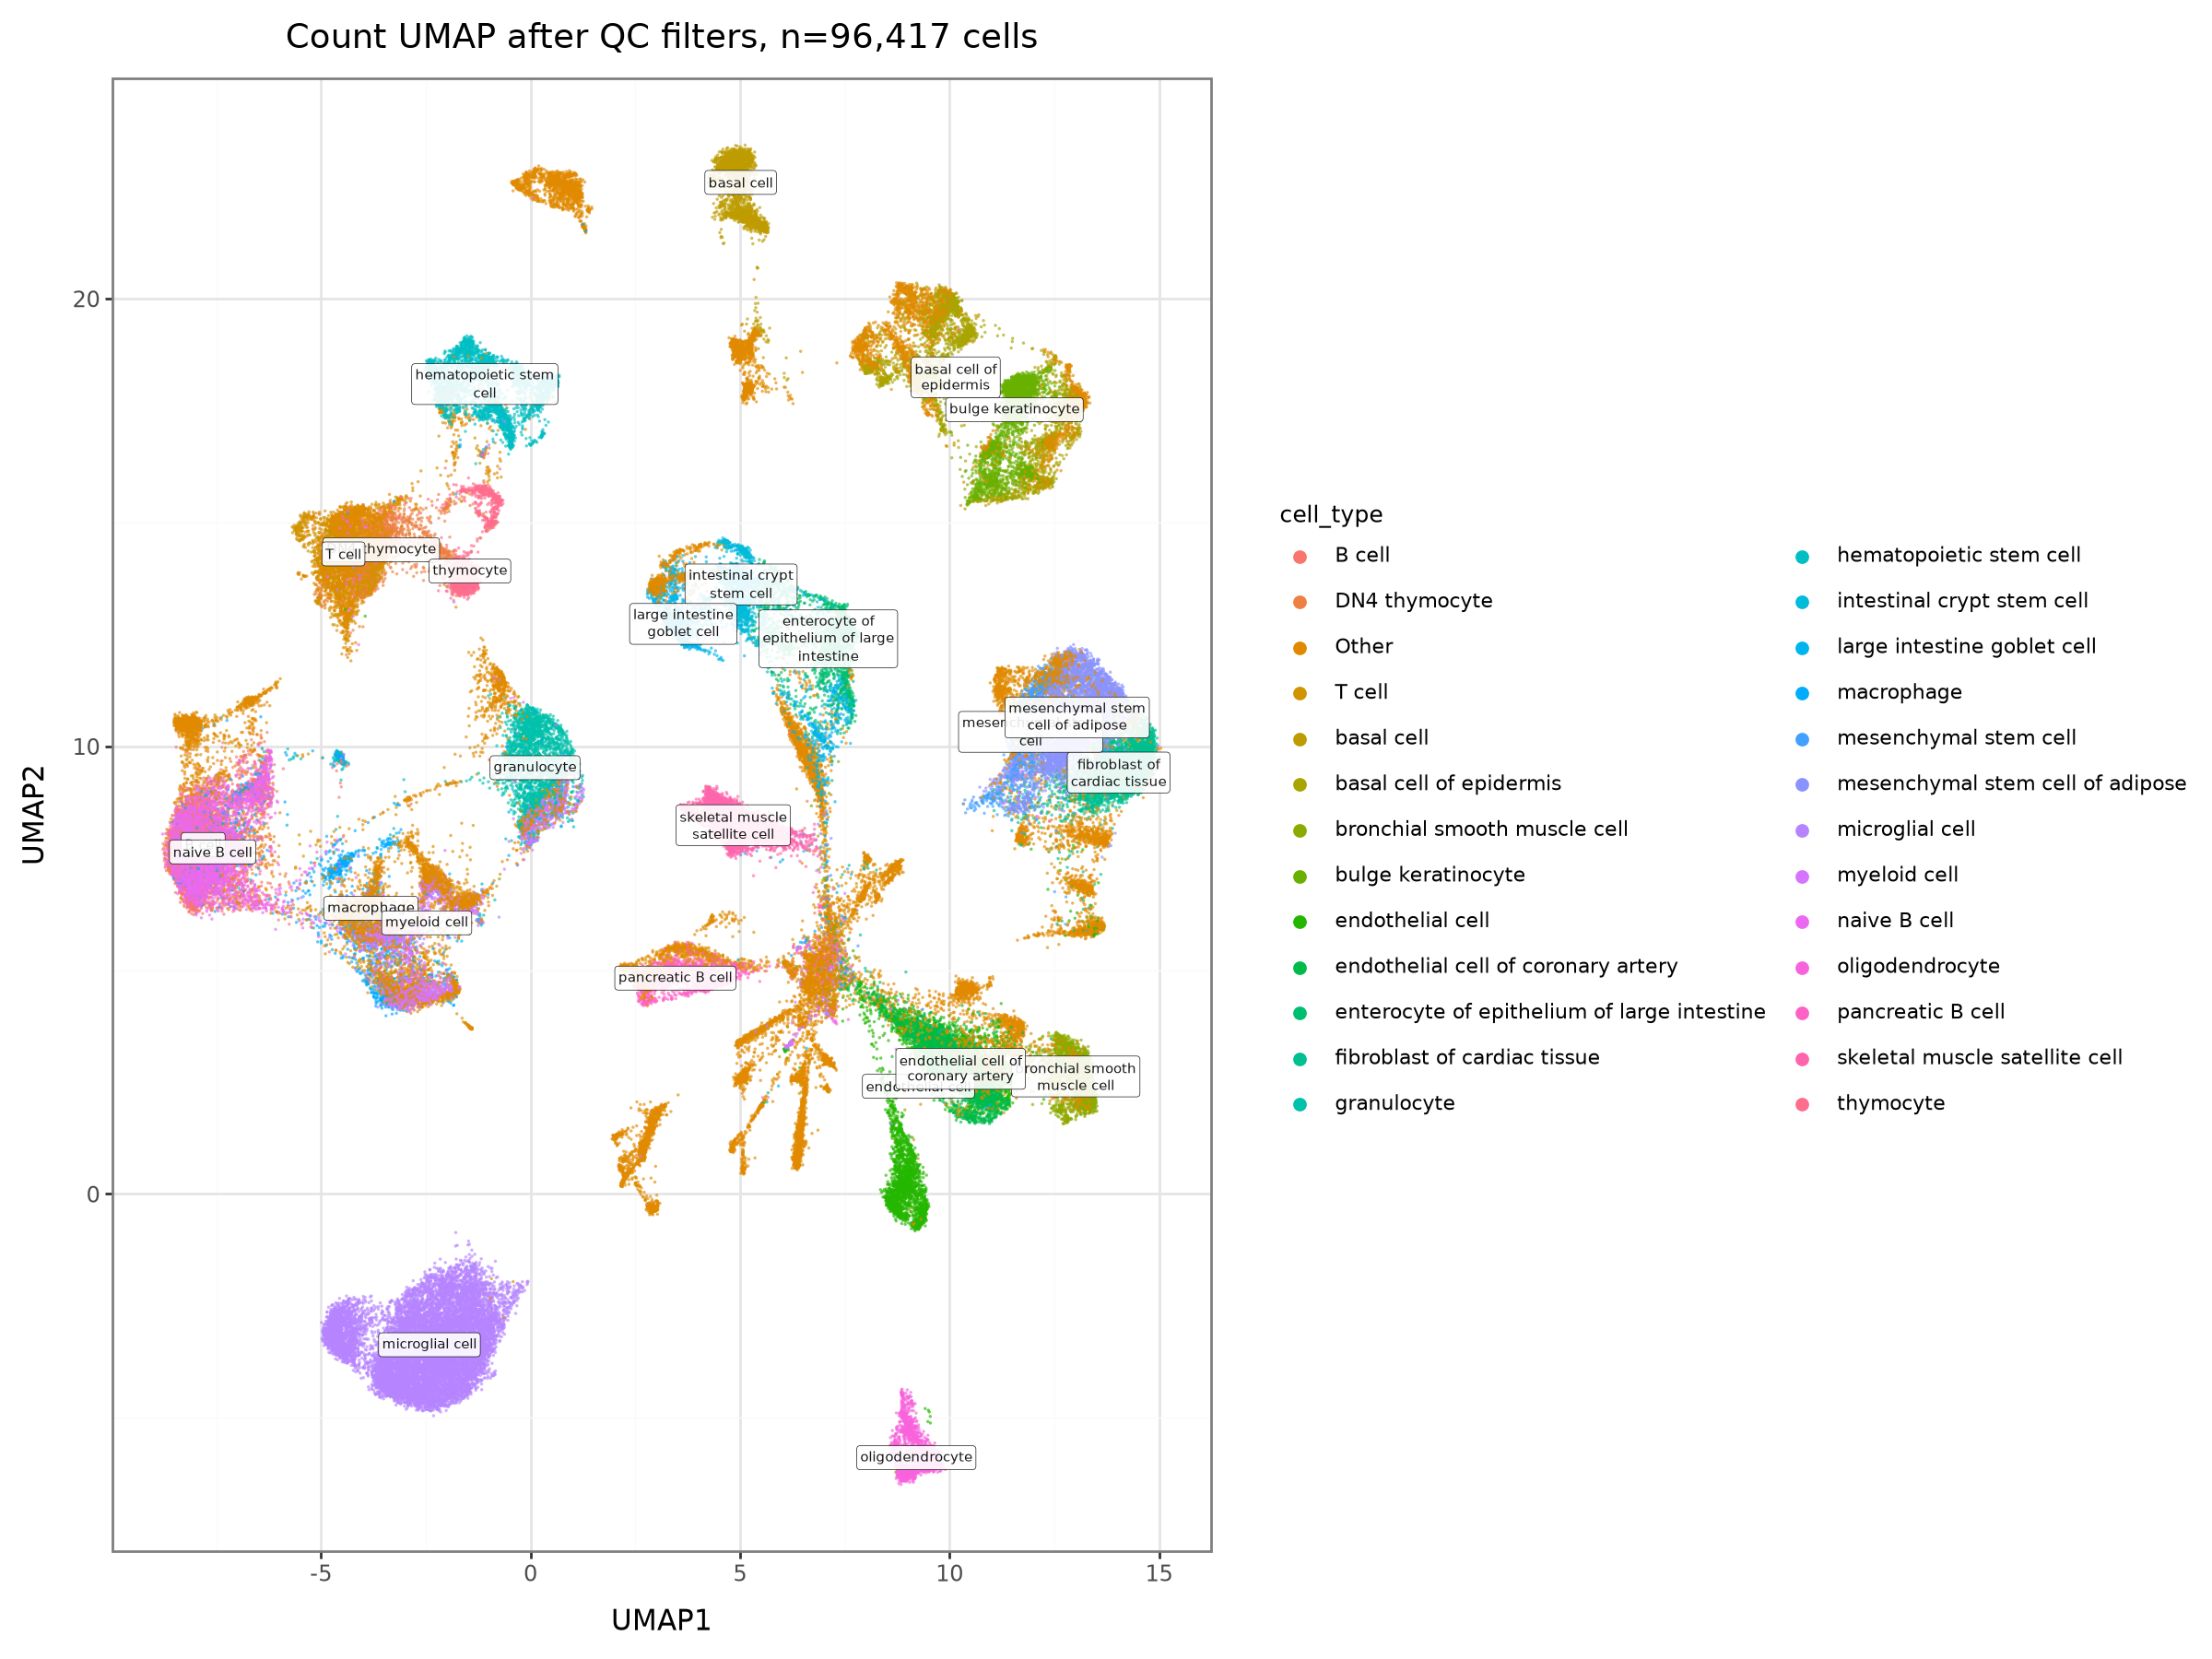

In [7]:
if cell_type_col is not None:
    top_types = umap_df[cell_type_col].value_counts().head(25).index
    count_plot_df = umap_df.copy()
    count_plot_df['plot_cell_type'] = np.where(count_plot_df[cell_type_col].isin(top_types), count_plot_df[cell_type_col], 'Other')
    count_label_df = (
        count_plot_df[count_plot_df['plot_cell_type'] != 'Other']
        .groupby('plot_cell_type', as_index=False)[['UMAP1', 'UMAP2']]
        .median()
    )
    count_label_df['plot_label'] = count_label_df['plot_cell_type'].map(lambda label: textwrap.fill(label, width=20))
    p_count_umap = (
        ggplot(count_plot_df, aes('UMAP1', 'UMAP2', color='plot_cell_type'))
        + geom_point(size=0.7, alpha=0.65, stroke=0)
        + geom_label(
            count_label_df,
            aes('UMAP1', 'UMAP2', label='plot_label'),
            inherit_aes=False,
            size=5.5,
            alpha=0.9,
            fill='white',
            color='black',
            label_size=0.25,
            show_legend=False,
        )
        + labs(color=cell_type_col, title=f'Count UMAP after QC filters, n={len(count_plot_df):,} cells')
        + guides(color=guide_legend(override_aes={'size': 3, 'alpha': 1}))
        + theme_bw()
        + theme(figure_size=(12, 9), legend_title=element_text(size=9), legend_text=element_text(size=8))
    )
else:
    count_plot_df = umap_df.copy()
    p_count_umap = (
        ggplot(count_plot_df, aes('UMAP1', 'UMAP2'))
        + geom_point(size=0.7, alpha=0.65, stroke=0)
        + labs(title=f'Count UMAP after QC filters, n={len(count_plot_df):,} cells')
        + theme_bw()
        + theme(figure_size=(9, 8))
    )
display(p_count_umap)

## PSI UMAP

This embedding uses the same cells and count-filtered events retained by the UMAP QC filters. PSI is centered per event using observed PSI values only. The SVD is a randomized power-iteration SVD over an implicit centered `LinearOperator`, so the centered cell-by-event matrix is never materialized. Missing pairs are zero after centering, while true observed PSI values of zero remain valid observations.

In [8]:
psi = sp.load_npz(PSI_NPZ).tocsr()
psi_obs = sp.load_npz(PSI_OBS_NPZ).tocsr()
print('psi:', psi.shape, 'nnz=', f'{psi.nnz:,}', 'stored zero PSI values=', int((psi.data == 0).sum()))
print('psi observed:', psi_obs.shape, 'nnz=', f'{psi_obs.nnz:,}', 'explicit zeros=', int((psi_obs.data == 0).sum()))

psi_qc = psi[eligible_cell_idx][:, eligible_event_idx].astype(np.float32).tocsr()
psi_qc.data = psi_qc.data / 100.0
psi_obs_qc = psi_obs[eligible_cell_idx][:, eligible_event_idx].tocsr()
observed_per_event_for_psi = np.asarray(psi_obs_qc.getnnz(axis=0)).ravel()
raw_event_mean = np.divide(
    np.asarray(psi_qc.sum(axis=0)).ravel(),
    observed_per_event_for_psi,
    out=np.zeros_like(observed_per_event_for_psi, dtype=np.float32),
    where=observed_per_event_for_psi > 0,
)
psi_event_keep = observed_per_event_for_psi > 0
psi_event_idx = eligible_event_idx[psi_event_keep]
event_psi_mean = raw_event_mean[psi_event_keep].astype(np.float32)
print(f'PSI events retained after observed-value check: {len(psi_event_idx):,} / {len(eligible_event_idx):,}')
print(f'Median observed PSI cells per retained event: {np.median(observed_per_event_for_psi[psi_event_keep]):,.0f}')
print('Retained PSI events by type:')
display(var.iloc[psi_event_idx]['event_type'].value_counts().rename_axis('event_type').reset_index(name='n_events'))
del psi_qc, psi_obs_qc

psi_sample = psi[sample_idx][:, psi_event_idx].astype(np.float32).tocsr()
psi_sample.data = psi_sample.data / 100.0
psi_obs_sample = psi_obs[sample_idx][:, psi_event_idx].astype(np.float32).tocsr()
print(f'Observed PSI sample matrix: {psi_sample.shape}, nnz={psi_sample.nnz:,}')

# Implicit centered operator: A_ij = observed_ij * (psi_ij - event_mean_j).
def centered_psi_operator(values, observed, event_mean):
    values = values.tocsr().astype(np.float32)
    observed = observed.tocsr().astype(np.float32)
    event_mean = np.asarray(event_mean, dtype=np.float32)
    shape = values.shape

    def matmat(x):
        x = np.asarray(x, dtype=np.float32)
        return values @ x - observed @ (event_mean[:, None] * x)

    def rmatmat(x):
        x = np.asarray(x, dtype=np.float32)
        return values.T @ x - event_mean[:, None] * (observed.T @ x)

    def matvec(x):
        return matmat(np.asarray(x, dtype=np.float32)[:, None]).ravel()

    def rmatvec(x):
        return rmatmat(np.asarray(x, dtype=np.float32)[:, None]).ravel()

    return LinearOperator(shape, matvec=matvec, rmatvec=rmatvec, matmat=matmat, rmatmat=rmatmat, dtype=np.float32)


def randomized_power_svd(operator, n_components, *, n_oversamples=10, n_iter=3, random_state=13):
    rng = np.random.default_rng(random_state)
    n_random = min(operator.shape[1], n_components + n_oversamples)
    omega = rng.standard_normal((operator.shape[1], n_random), dtype=np.float32)
    q = operator.matmat(omega)
    q, _ = np.linalg.qr(q, mode='reduced')
    q = q.astype(np.float32, copy=False)

    for _ in range(n_iter):
        z = operator.rmatmat(q)
        z, _ = np.linalg.qr(z, mode='reduced')
        z = z.astype(np.float32, copy=False)
        q = operator.matmat(z)
        q, _ = np.linalg.qr(q, mode='reduced')
        q = q.astype(np.float32, copy=False)

    # Small dense matrix only: n_random x n_events, not cells x events.
    b = operator.rmatmat(q).T
    u_hat, singular_values, vt = np.linalg.svd(b, full_matrices=False)
    u = q @ u_hat[:, :n_components]
    singular_values = singular_values[:n_components]
    vt = vt[:n_components]
    return u.astype(np.float32, copy=False), singular_values.astype(np.float32, copy=False), vt.astype(np.float32, copy=False)

A_psi = centered_psi_operator(psi_sample, psi_obs_sample, event_psi_mean)
n_components = min(N_COMPONENTS, A_psi.shape[0] - 1, A_psi.shape[1] - 1)
psi_u, psi_s, psi_vt = randomized_power_svd(
    A_psi,
    n_components,
    n_oversamples=10,
    n_iter=3,
    random_state=RANDOM_STATE,
)
X_psi_svd = psi_u * psi_s[None, :]

sample_event_sum = np.asarray(psi_sample.sum(axis=0)).ravel()
sample_event_sumsq = np.asarray(psi_sample.multiply(psi_sample).sum(axis=0)).ravel()
sample_observed_per_event = np.asarray(psi_obs_sample.getnnz(axis=0)).ravel()
centered_sumsq = sample_event_sumsq - 2 * event_psi_mean * sample_event_sum + sample_observed_per_event * event_psi_mean**2
total_centered_sumsq = float(np.maximum(centered_sumsq.sum(), 0.0))
print(f'Implicit centered PSI operator: {A_psi.shape}, observed nnz={psi_sample.nnz:,}')
print(f'Power-iteration SVD captured centered sumsq ratio: {float(np.sum(psi_s**2) / total_centered_sumsq):.6f}')
print('Top centered PSI singular values:', np.array2string(psi_s[:5], precision=3))

psi_reducer = UMAP(n_neighbors=30, min_dist=0.3, metric='euclidean', random_state=RANDOM_STATE, n_jobs=1, verbose=False)
psi_embedding = psi_reducer.fit_transform(X_psi_svd)

psi_umap_df = pd.DataFrame(psi_embedding, columns=['UMAP1', 'UMAP2'], index=obs.index[sample_idx])
if cell_type_col is not None:
    psi_umap_df[cell_type_col] = obs.iloc[sample_idx][cell_type_col].astype(str).values
psi_umap_df.head()

psi: (107521, 128990) nnz= 234,285,123 stored zero PSI values= 96498531


psi observed: (107521, 128990) nnz= 234,285,123 explicit zeros= 0


PSI events retained after observed-value check: 51,075 / 51,075
Median observed PSI cells per retained event: 397
Retained PSI events by type:


,event_type,n_events
0,SE,36495
1,A3SS,5358
2,RI,3899
3,A5SS,3095
4,MXE,2228


Observed PSI sample matrix: (96417, 51075), nnz=231,321,316


Implicit centered PSI operator: (96417, 51075), observed nnz=231,321,316
Power-iteration SVD captured centered sumsq ratio: 0.071479
Top centered PSI singular values: [218.01  181.601 169.365 165.432 154.763]


,UMAP1,UMAP2,cell_type
safe_cell_id,,,
A1-B000971-3_39_F-1-1,-8.045624,11.119560,B cell
A1-MAA000508-3_9_M-1-1,-8.982095,10.810762,B cell
A1-MAA000779-3_11_M-1-1,-5.506001,13.382363,B cell
A10-MAA000556-3_9_M-1-1,-7.128769,12.521380,B cell
A10-MAA000779-3_11_M-1-1,-8.936152,12.370572,B cell


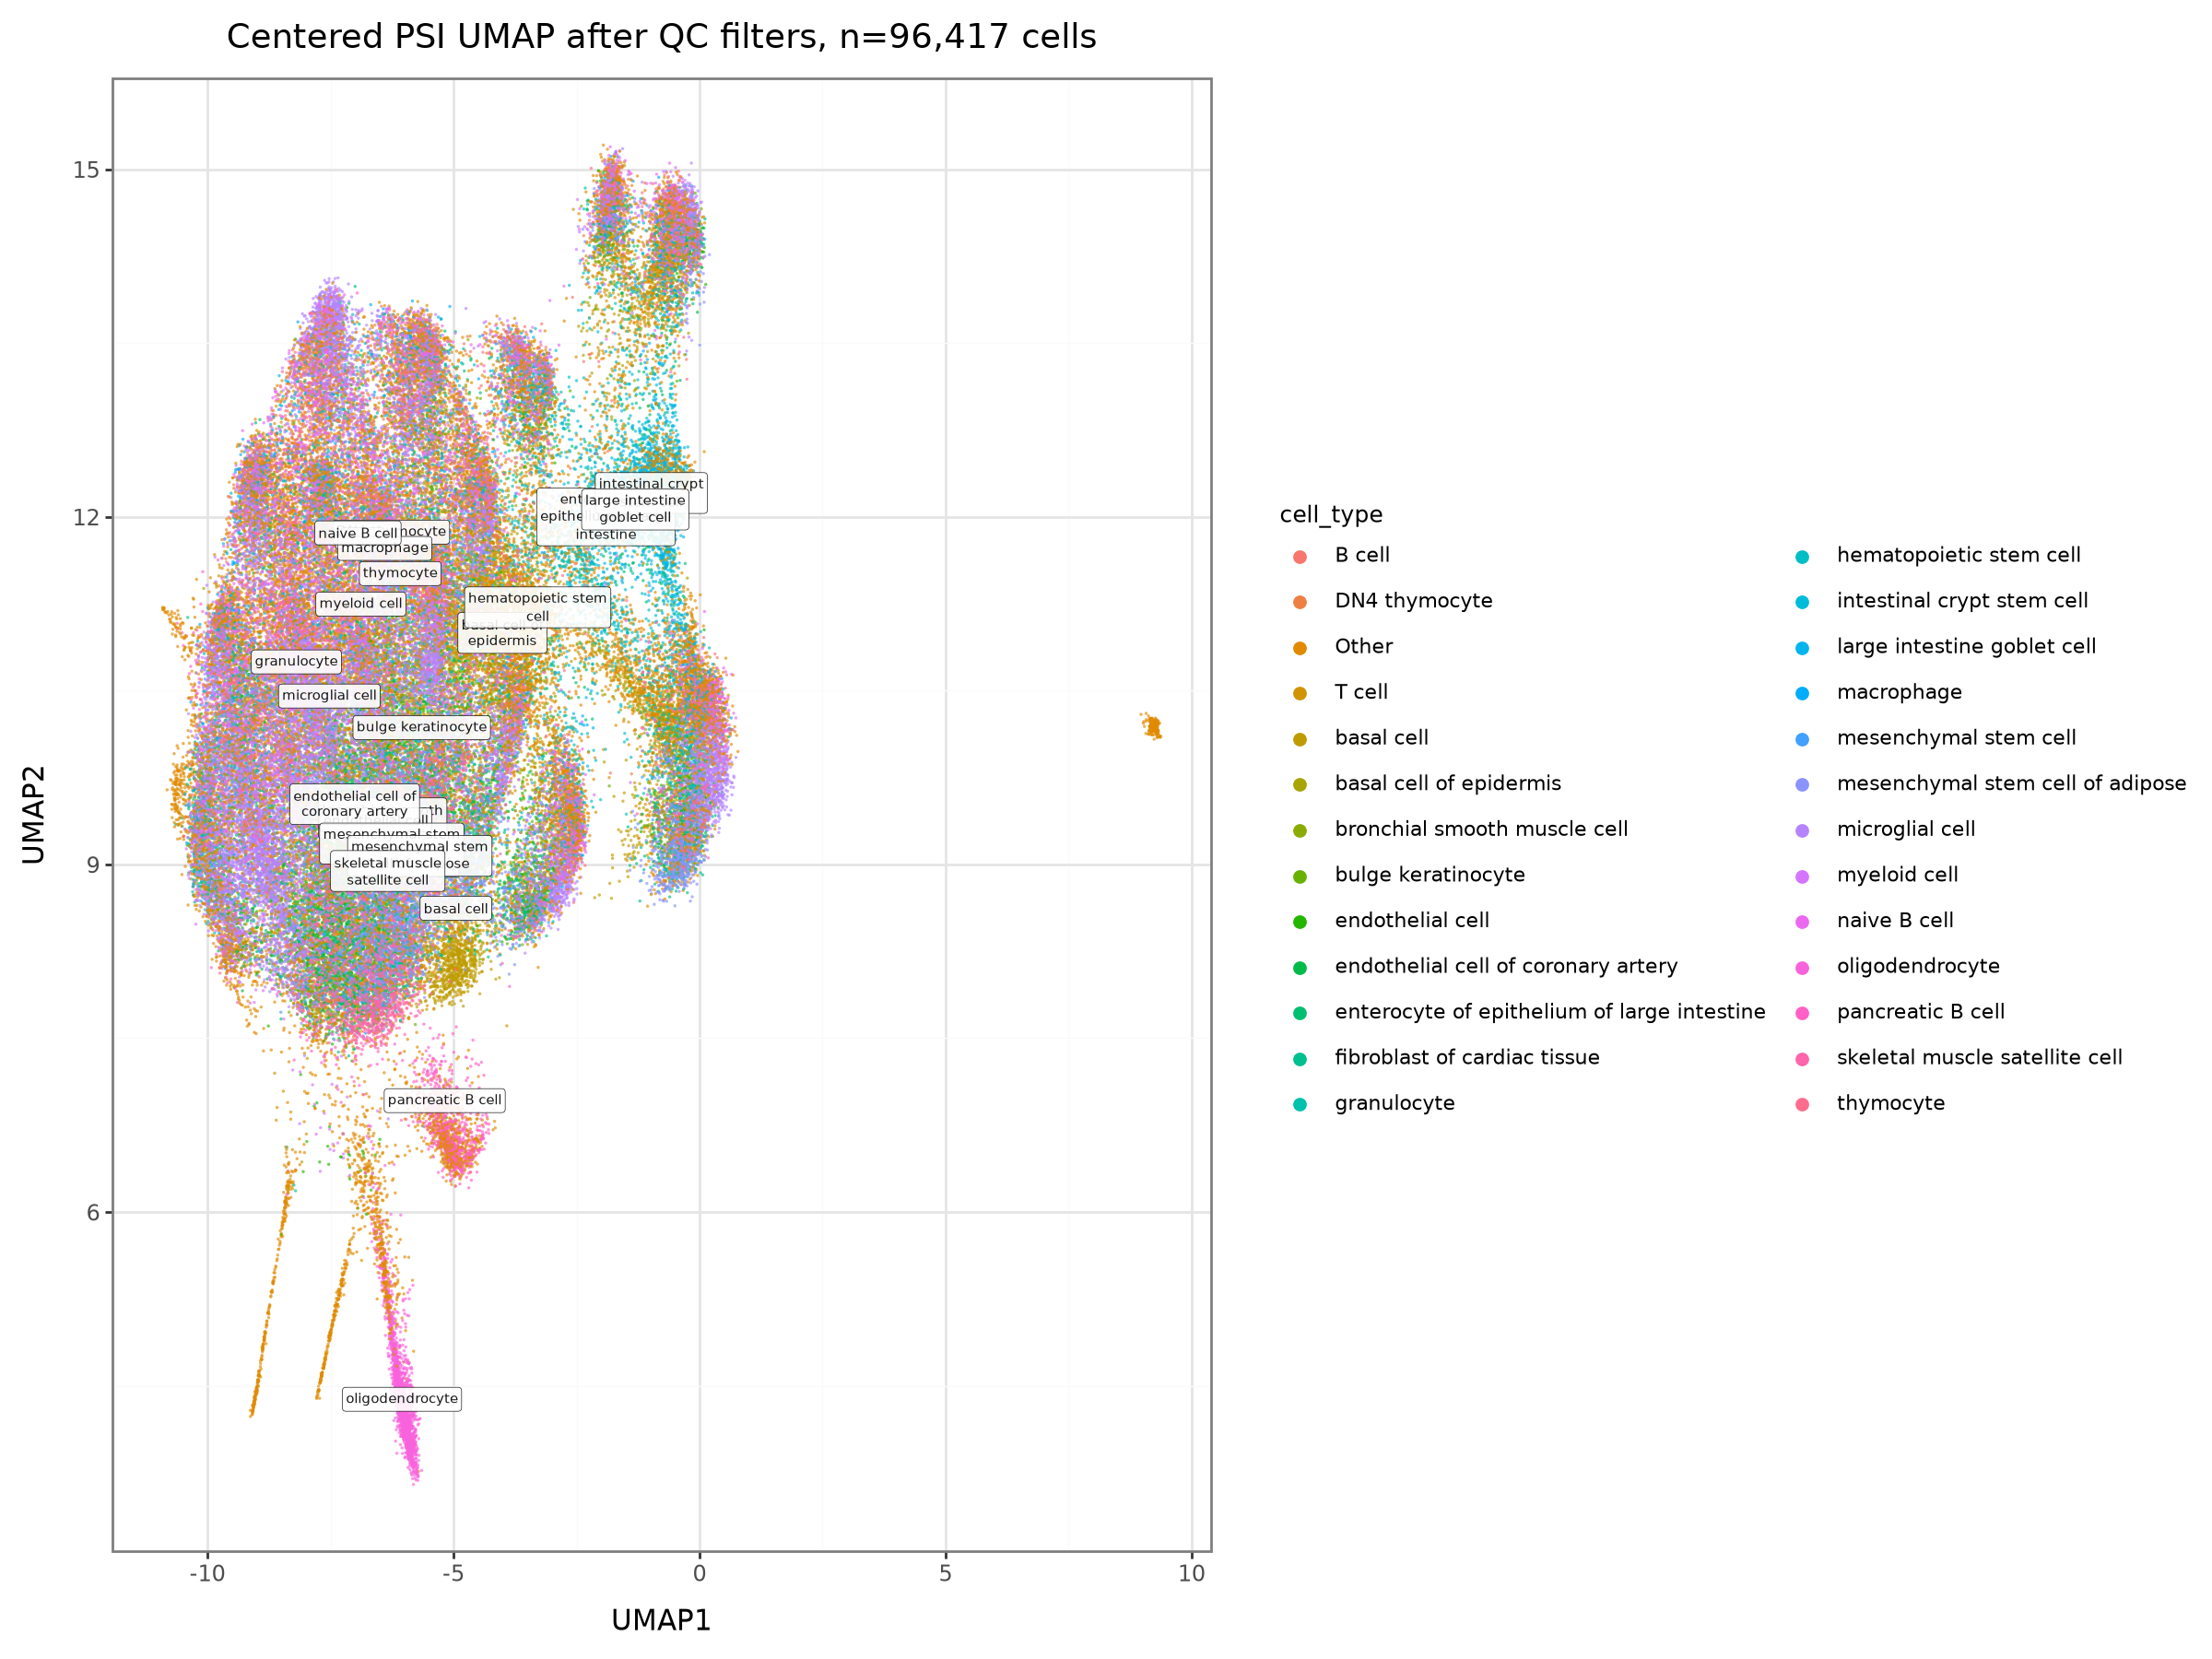

In [9]:
if cell_type_col is not None:
    top_types = psi_umap_df[cell_type_col].value_counts().head(25).index
    psi_plot_df = psi_umap_df.copy()
    psi_plot_df['plot_cell_type'] = np.where(psi_plot_df[cell_type_col].isin(top_types), psi_plot_df[cell_type_col], 'Other')
    psi_label_df = (
        psi_plot_df[psi_plot_df['plot_cell_type'] != 'Other']
        .groupby('plot_cell_type', as_index=False)[['UMAP1', 'UMAP2']]
        .median()
    )
    psi_label_df['plot_label'] = psi_label_df['plot_cell_type'].map(lambda label: textwrap.fill(label, width=20))
    p_psi_umap = (
        ggplot(psi_plot_df, aes('UMAP1', 'UMAP2', color='plot_cell_type'))
        + geom_point(size=0.7, alpha=0.65, stroke=0)
        + geom_label(
            psi_label_df,
            aes('UMAP1', 'UMAP2', label='plot_label'),
            inherit_aes=False,
            size=5.5,
            alpha=0.9,
            fill='white',
            color='black',
            label_size=0.25,
            show_legend=False,
        )
        + labs(color=cell_type_col, title=f'Centered PSI UMAP after QC filters, n={len(psi_plot_df):,} cells')
        + guides(color=guide_legend(override_aes={'size': 3, 'alpha': 1}))
        + theme_bw()
        + theme(figure_size=(12, 9), legend_title=element_text(size=9), legend_text=element_text(size=8))
    )
else:
    psi_plot_df = psi_umap_df.copy()
    p_psi_umap = (
        ggplot(psi_plot_df, aes('UMAP1', 'UMAP2'))
        + geom_point(size=0.7, alpha=0.65, stroke=0)
        + labs(title=f'Centered PSI UMAP after QC filters, n={len(psi_plot_df):,} cells')
        + theme_bw()
        + theme(figure_size=(9, 8))
    )
display(p_psi_umap)